In [1]:
from src.model import PyTradeShifts
from src.postprocessing import Postprocessing
import pandas as pd
import os
os.chdir('../../')
print(os.getcwd())

/home/florian/Documents/GitHub/pytradeshifts


# AMOC Collapse — Trade After Catastrophe

This notebook analyses the impact of an AMOC (Atlantic Meridional Overturning Circulation) collapse on global agricultural trade for **Wheat**, **Maize**, and **Rice** using base year **2023**.

The yield reduction data comes from `data/scenario_files/AMOC Collapse/country_total_calories_decline.csv`, which contains per-crop percentage changes in production for each country.

The analyses shown here are:
- **Relative import difference** between the base scenario and the AMOC collapse scenario
- **Trade communities** in both the base and AMOC collapse scenario
- **Trade community change** (how communities reorganise under AMOC collapse)
- **Jaccard distance** (how much each country's trade community membership changes)

## Prepare per-crop scenario files

The AMOC CSV contains yield changes for all crops in a single file. `PyTradeShifts` expects one file per crop with the country as index and a single value column. We extract the relevant columns here and write them to the `AMOC Collapse` scenario folder.

In [2]:
import country_converter as coco

amoc_raw = pd.read_csv(
    "data/scenario_files/AMOC Collapse/country_total_calories_decline.csv",
    index_col=0,
)

cc = coco.CountryConverter()

# Crop column mapping: model crop name -> column in the AMOC CSV
crop_columns = {
    "Wheat": "wheat_total_change_pct",
    "Maize": "maize_total_change_pct",
    "Rice":  "rice_total_change_pct",
}

for crop, col in crop_columns.items():
    crop_data = amoc_raw[[col]].dropna().copy()
    # Pre-check which country names convert cleanly (apply_scenario does the same conversion).
    # Entries that resolve to "not found" or create duplicates would cause a reindex error.
    converted = cc.pandas_convert(pd.Series(crop_data.index), to="name_short")
    valid = (converted != "not found") & (~converted.duplicated(keep="first"))
    dropped = crop_data.index[~valid.values].tolist()
    if dropped:
        print(f"{crop}: dropping unresolvable/duplicate countries: {dropped}")
    crop_data = crop_data[valid.values]
    out_path = f"data/scenario_files/AMOC Collapse/{crop.lower()}_amoc_collapse.csv"
    crop_data.to_csv(out_path)
    print(f"{crop}: {len(crop_data)} countries affected, median yield change = {crop_data[col].median():.2f}%")

Wheat: dropping unresolvable/duplicate countries: ['S. Sudan']
Wheat: 130 countries affected, median yield change = -6.19%
Maize: dropping unresolvable/duplicate countries: ['S. Sudan', 'Somalia']
Maize: 153 countries affected, median yield change = -3.41%
Rice: dropping unresolvable/duplicate countries: ['S. Sudan']
Rice: 116 countries affected, median yield change = -1.82%


---
## Wheat

In [3]:
base_year = 2023

wheat_base = PyTradeShifts(
    "Wheat",
    base_year=base_year,
    region="Global",
    testing=False,
    cd_kwargs={"seed": 2},
    make_plot=False,
)
wheat_amoc = PyTradeShifts(
    crop="Wheat",
    base_year=base_year,
    scenario_file_name="AMOC Collapse/wheat_amoc_collapse.csv",
    scenario_name="AMOC Collapse",
    cd_kwargs={"seed": 2},
    make_plot=False,
)

wheat_comparison = Postprocessing(
    [wheat_base, wheat_amoc],
    anchor_countries=["United States", "Russia", "Australia", "Germany"],
)

Loaded data for Wheat in Y2023.
Removed 2 countries with no trade or production.
Removed countries: ['Marshall Islands', 'Sao Tome and Principe']
Prebalanced trade matrix.
Corrected re-exports.
Removed countries with trade below the 75th percentile.
Built trade graph.
Found 7 trade communities.
Loaded data for Wheat in Y2023.
Removed 2 countries with no trade or production.
Removed countries: ['Marshall Islands', 'Sao Tome and Principe']
Prebalanced trade matrix.
Corrected re-exports.
Removed countries with trade below the 75th percentile.
Applied scenario AMOC Collapse.
Built trade graph.
Found 6 trade communities.
Starting postprocessing computations...


### Relative import difference (Wheat)

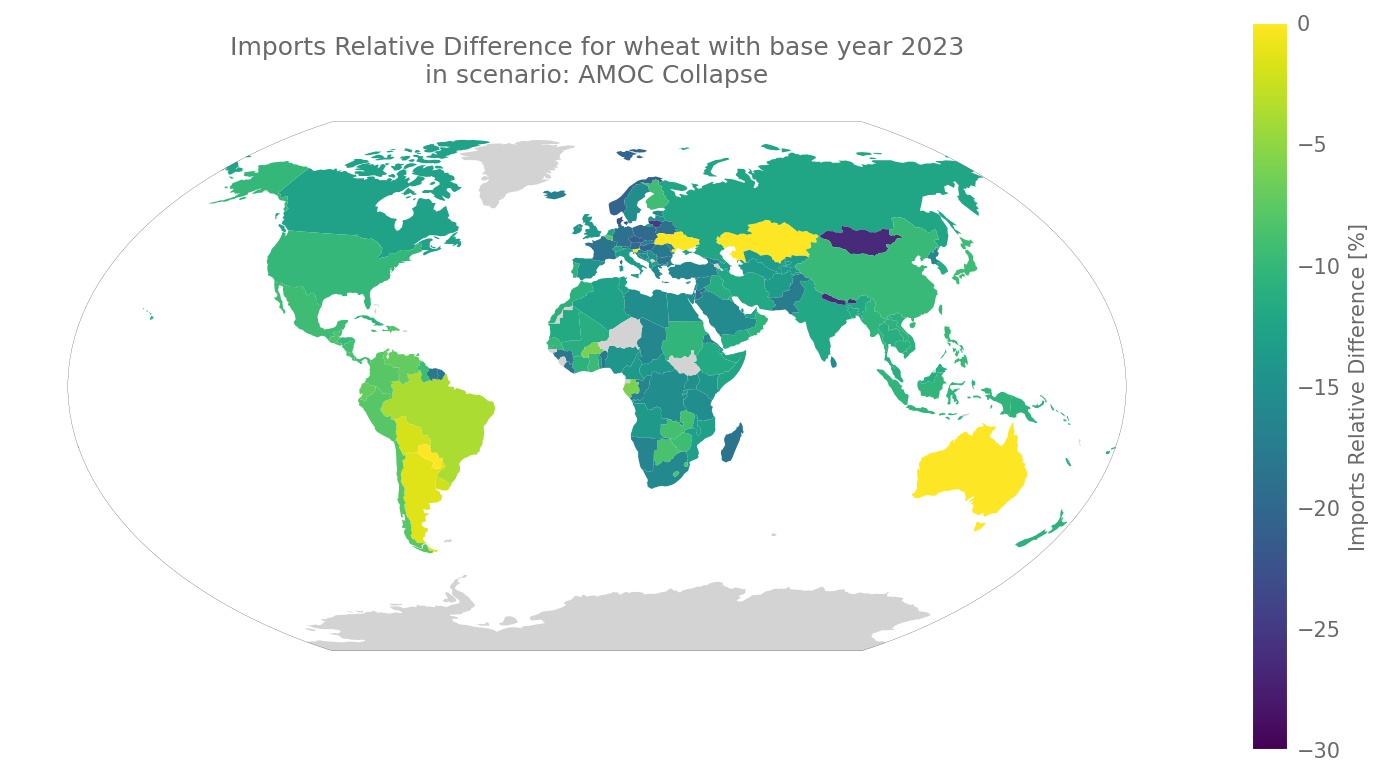

In [4]:
wheat_comparison.plot_imports_difference(figsize=(10, 10), vmin=-30, vmax=0, shrink=0.5)

### Trade communities (Wheat)

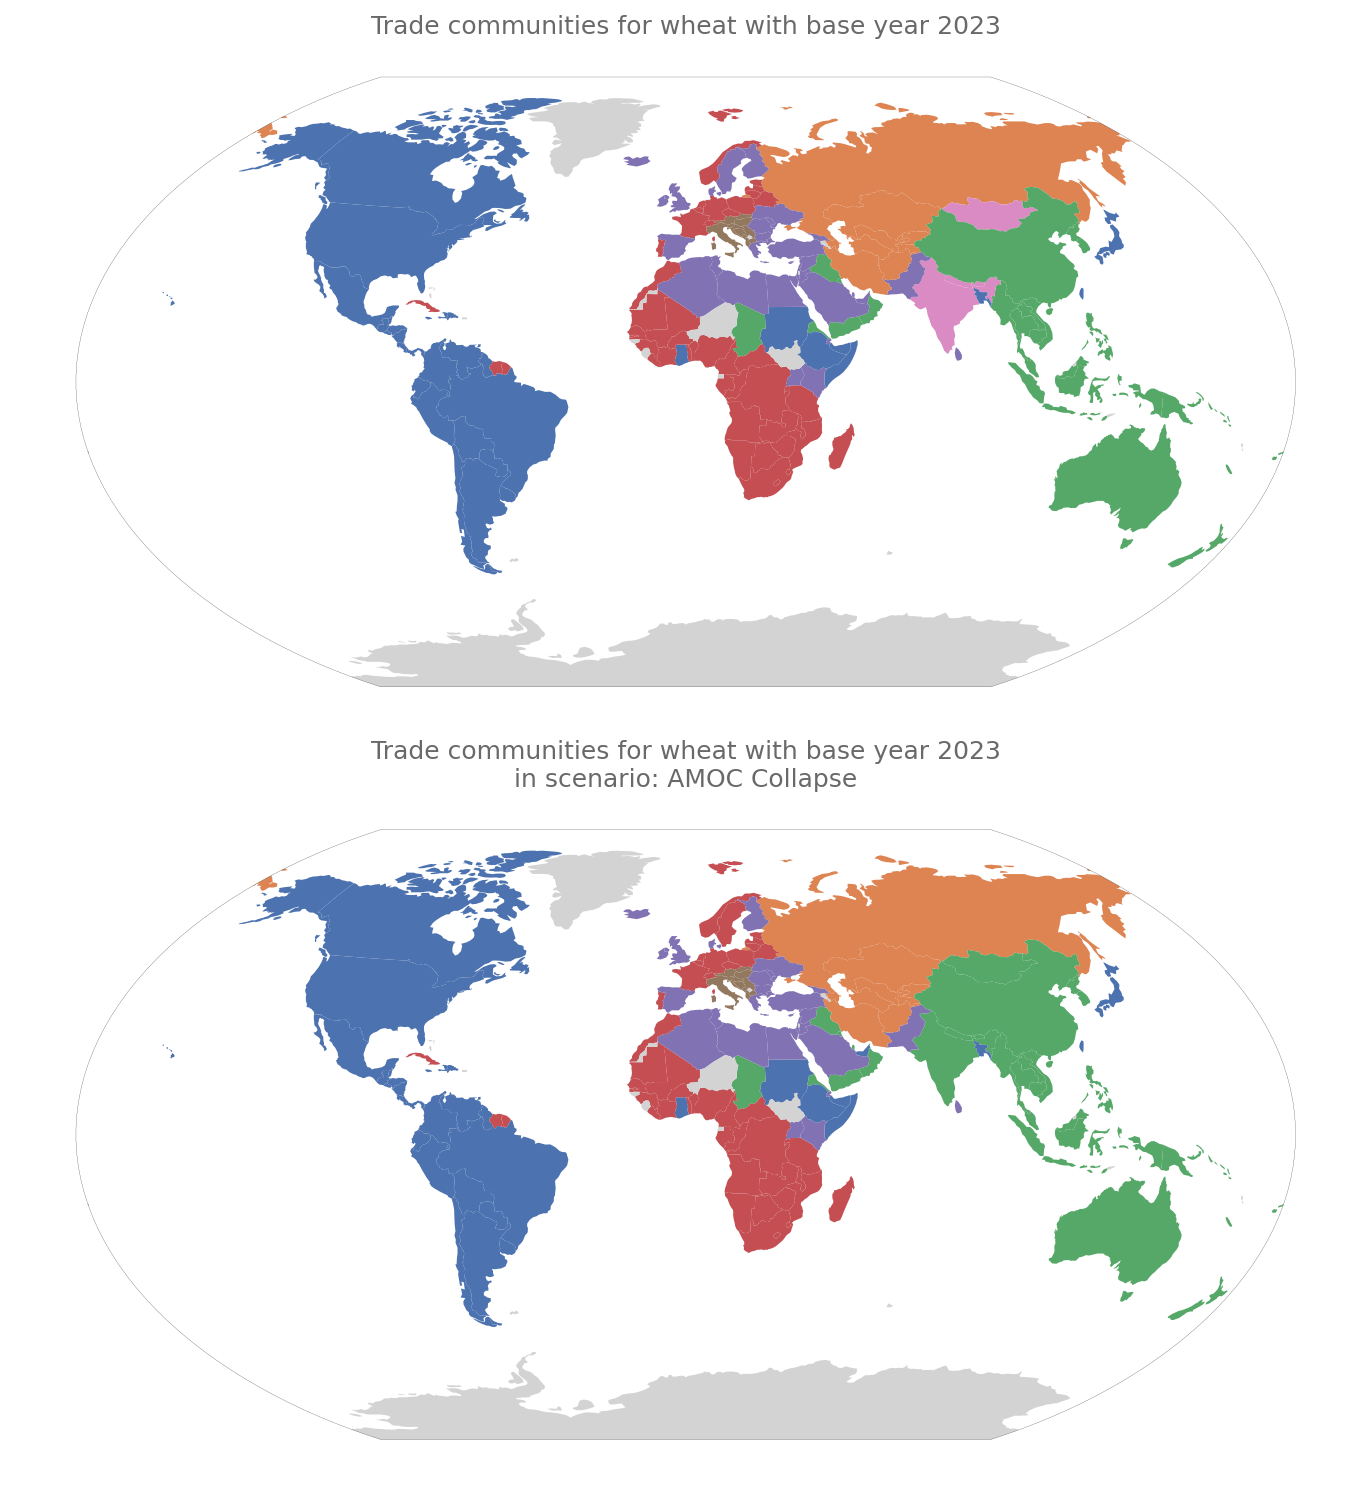

In [5]:
wheat_comparison.plot_all_trade_communities(figsize=(15, 10))

### Trade community change — Jaccard distance (Wheat)

The Jaccard distance (1 − Jaccard index) quantifies how much each country's trade community membership changed between the base scenario and the AMOC collapse scenario. A value of 0 means no change; a value of 1 means the country moved to a completely different community.

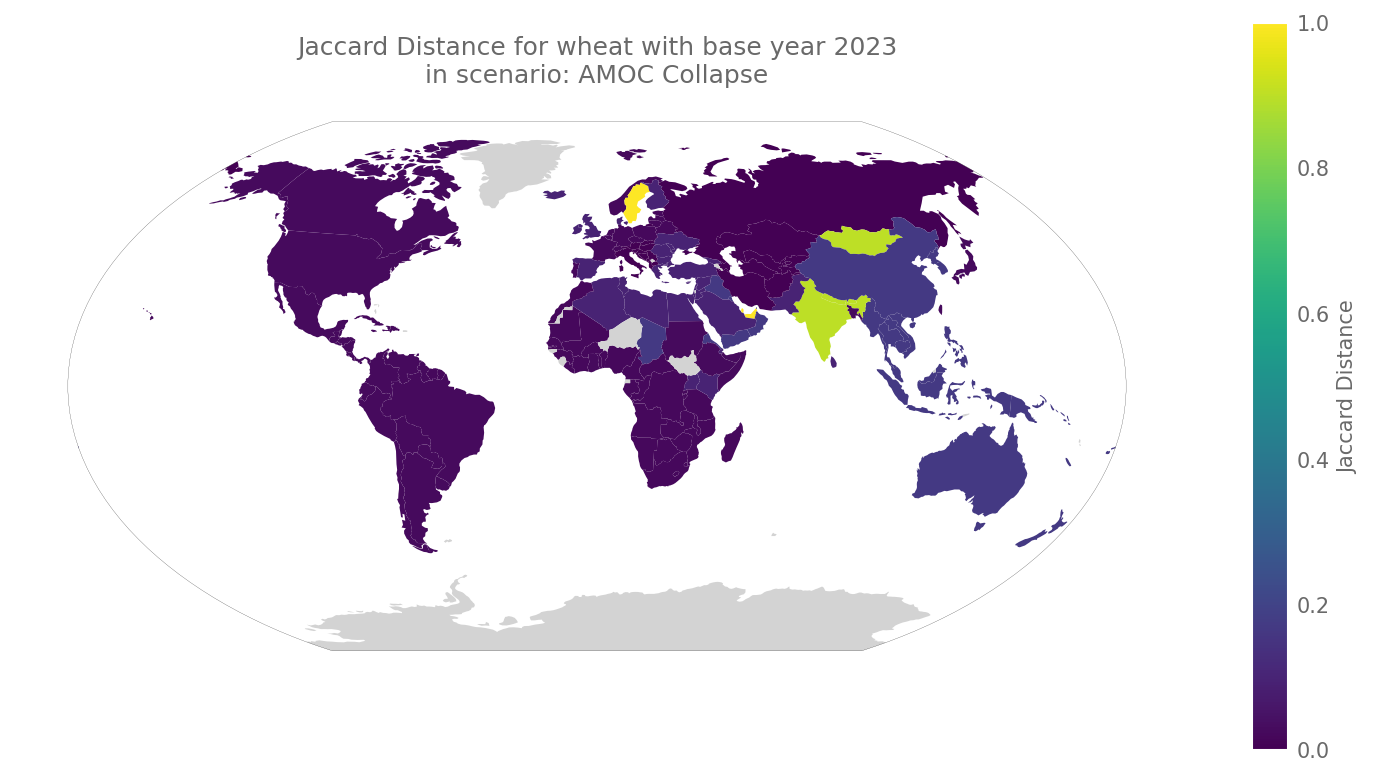

In [6]:
wheat_comparison.plot_community_difference(figsize=(10, 10), vmin=0, vmax=1, shrink=0.5)

---
## Maize

In [7]:
maize_base = PyTradeShifts(
    "Maize",
    base_year=base_year,
    region="Global",
    testing=False,
    cd_kwargs={"seed": 2},
    make_plot=False,
)
maize_amoc = PyTradeShifts(
    crop="Maize",
    base_year=base_year,
    scenario_file_name="AMOC Collapse/maize_amoc_collapse.csv",
    scenario_name="AMOC Collapse",
    cd_kwargs={"seed": 2},
    make_plot=False,
)

maize_comparison = Postprocessing(
    [maize_base, maize_amoc],
    anchor_countries=["United States", "India", "South Africa"],
)

The duplicates are the following: 
Index(['Micronesia, Fed. Sts.', 'Micronesia, Fed. Sts.'], dtype='object')
The duplicates are the following: 
Index(['Micronesia, Fed. Sts.', 'Micronesia, Fed. Sts.'], dtype='object')
Loaded data for Maize in Y2023.
Removed 0 countries with no trade or production.
No countries removed.
Prebalanced trade matrix.
Corrected re-exports.
Removed countries with trade below the 75th percentile.
Built trade graph.
Found 7 trade communities.
The duplicates are the following: 
Index(['Micronesia, Fed. Sts.', 'Micronesia, Fed. Sts.'], dtype='object')
The duplicates are the following: 
Index(['Micronesia, Fed. Sts.', 'Micronesia, Fed. Sts.'], dtype='object')
Loaded data for Maize in Y2023.
Removed 0 countries with no trade or production.
No countries removed.
Prebalanced trade matrix.
Corrected re-exports.
Removed countries with trade below the 75th percentile.
Applied scenario AMOC Collapse.
Built trade graph.
Found 7 trade communities.
Starting postprocessing co

### Relative import difference (Maize)

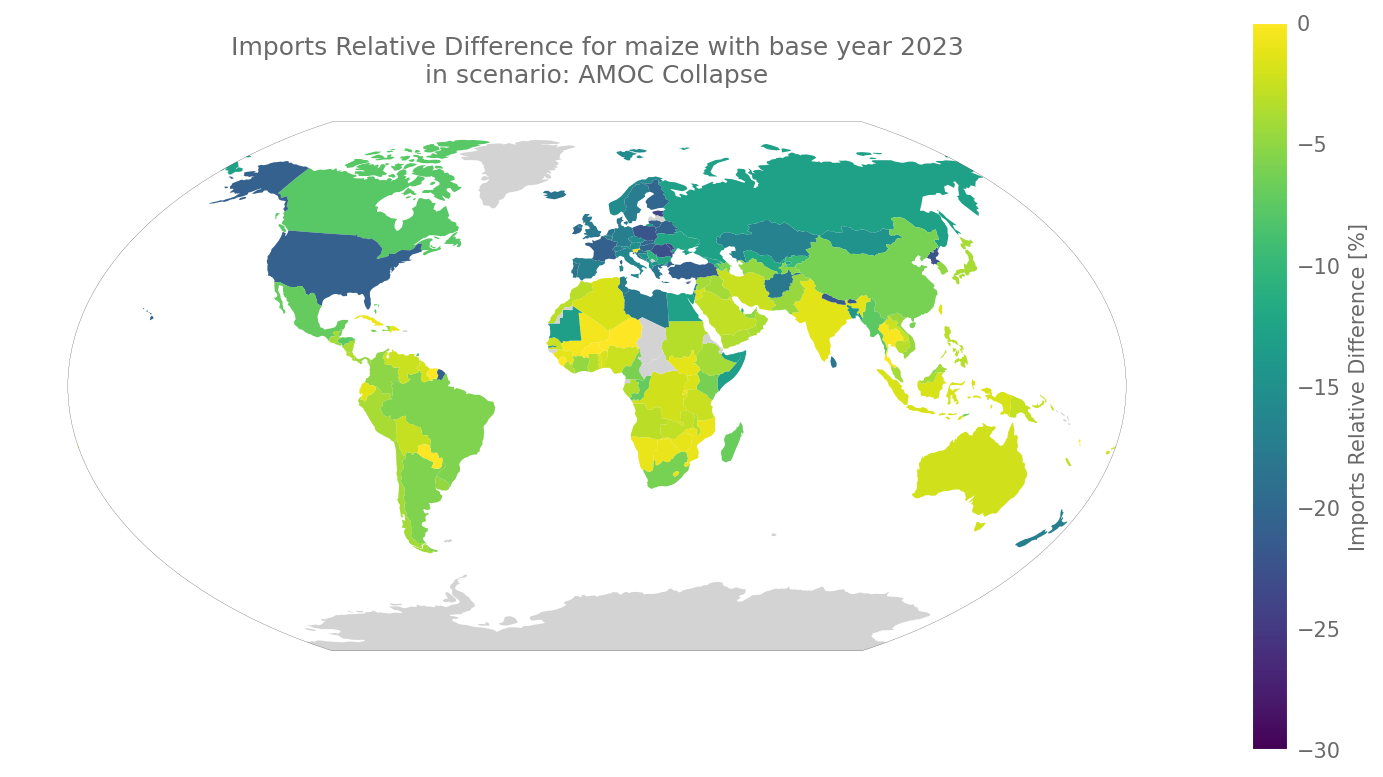

In [8]:
maize_comparison.plot_imports_difference(figsize=(10, 10), vmin=-30, vmax=0, shrink=0.5)

### Trade communities (Maize)

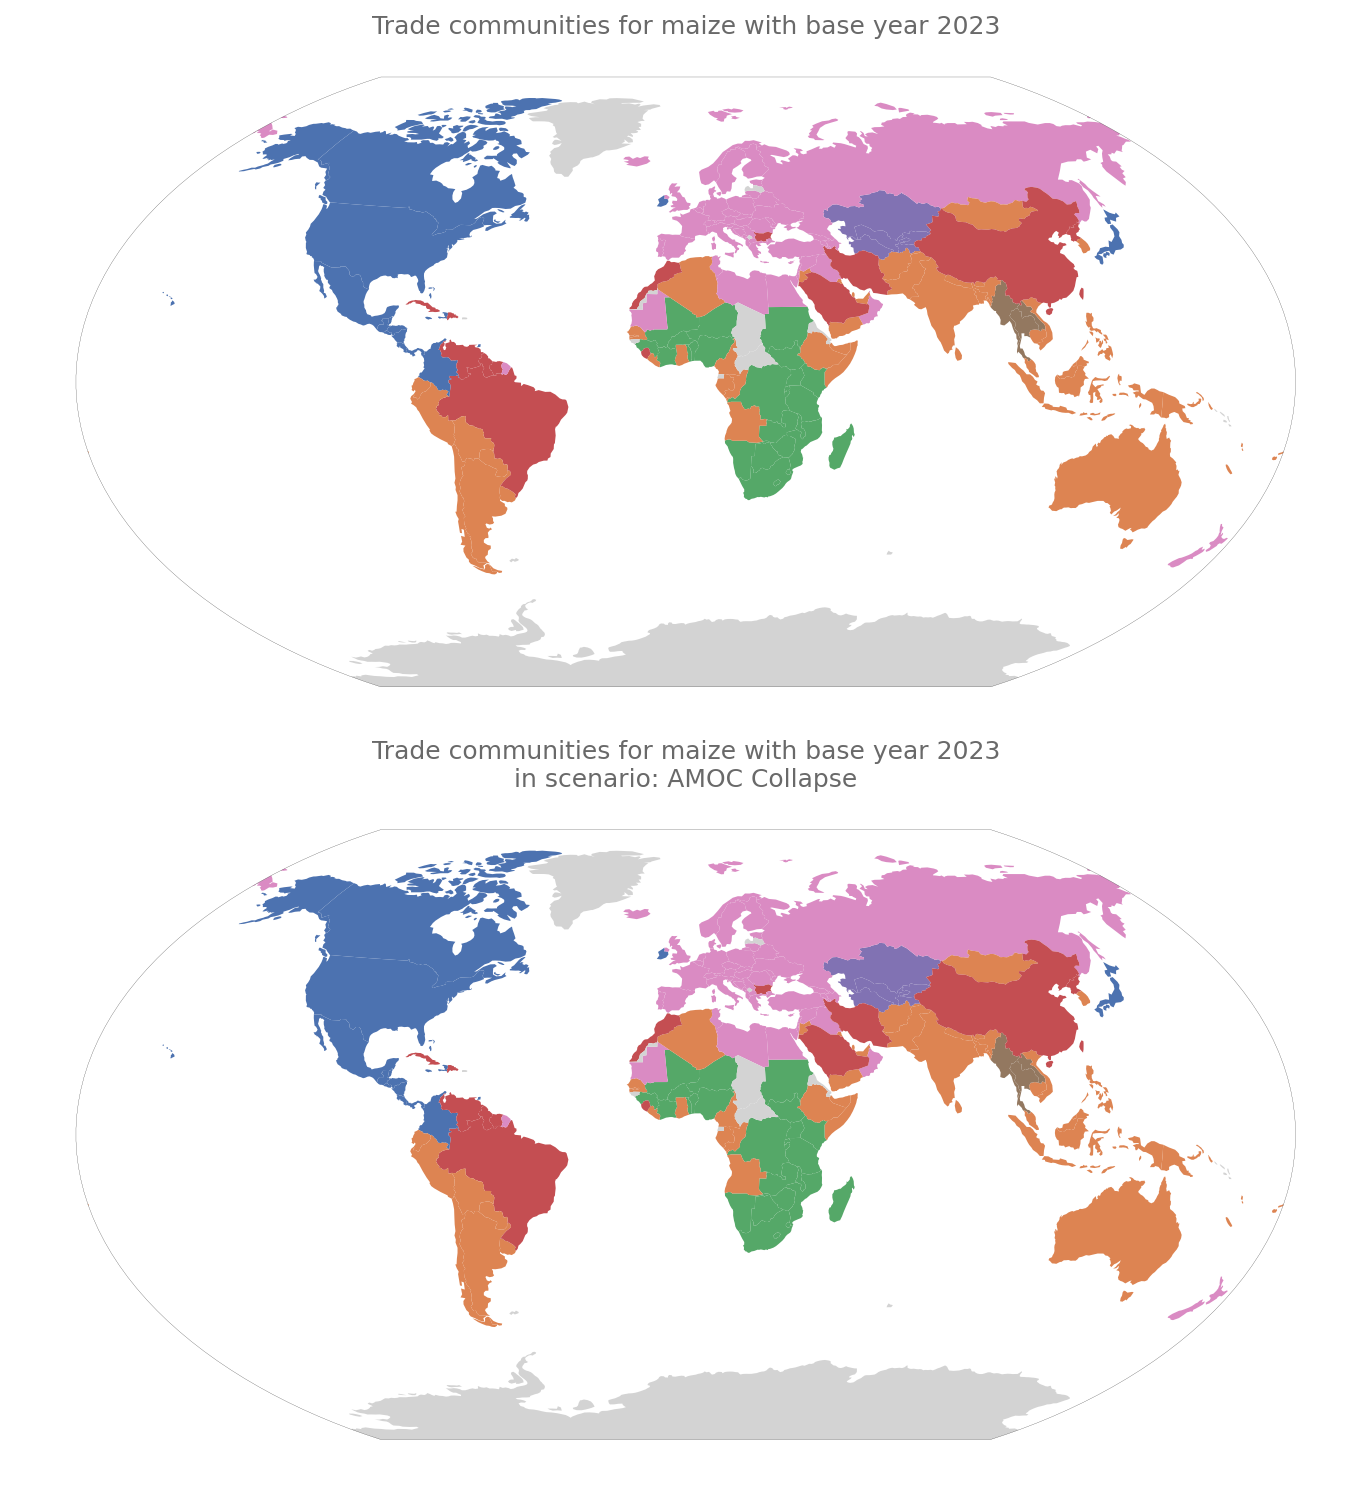

In [9]:
maize_comparison.plot_all_trade_communities(figsize=(15, 10))

### Trade community change — Jaccard distance (Maize)

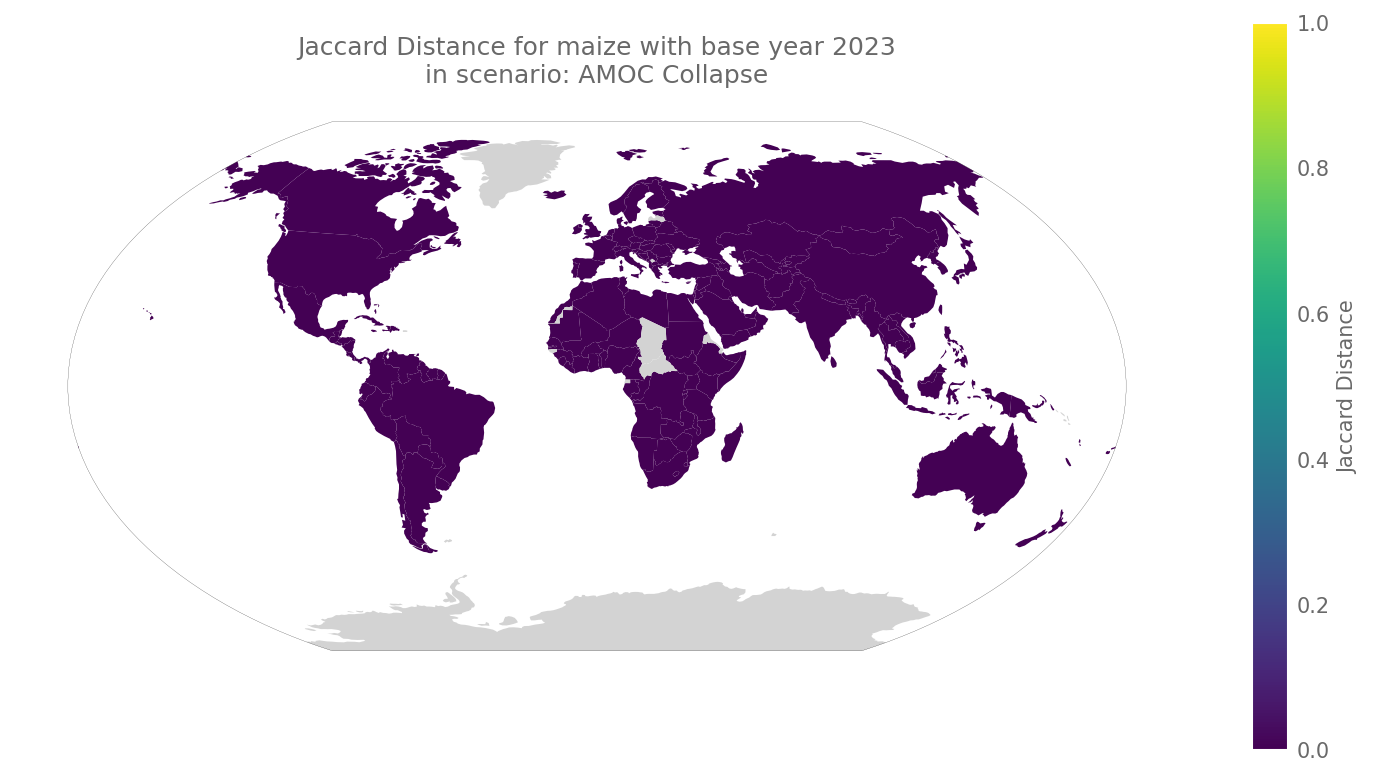

In [10]:
maize_comparison.plot_community_difference(figsize=(10, 10), vmin=0, vmax=1, shrink=0.5)

---
## Rice

In [11]:
rice_base = PyTradeShifts(
    "Rice",
    base_year=base_year,
    region="Global",
    testing=False,
    cd_kwargs={"seed": 2},
    make_plot=False,
)
rice_amoc = PyTradeShifts(
    crop="Rice",
    base_year=base_year,
    scenario_file_name="AMOC Collapse/rice_amoc_collapse.csv",
    scenario_name="AMOC Collapse",
    cd_kwargs={"seed": 2},
    make_plot=False,
)

rice_comparison = Postprocessing(
    [rice_base, rice_amoc],
    anchor_countries=["India", "Brazil"],
)

The duplicates are the following: 
Index(['Micronesia, Fed. Sts.', 'Micronesia, Fed. Sts.'], dtype='object')
The duplicates are the following: 
Index(['Micronesia, Fed. Sts.', 'Micronesia, Fed. Sts.'], dtype='object')
Loaded data for Rice in Y2023.
Removed 0 countries with no trade or production.
No countries removed.
Prebalanced trade matrix.
Corrected re-exports.
Removed countries with trade below the 75th percentile.
Built trade graph.
Found 5 trade communities.
The duplicates are the following: 
Index(['Micronesia, Fed. Sts.', 'Micronesia, Fed. Sts.'], dtype='object')
The duplicates are the following: 
Index(['Micronesia, Fed. Sts.', 'Micronesia, Fed. Sts.'], dtype='object')
Loaded data for Rice in Y2023.
Removed 0 countries with no trade or production.
No countries removed.
Prebalanced trade matrix.
Corrected re-exports.
Removed countries with trade below the 75th percentile.
Applied scenario AMOC Collapse.
Built trade graph.
Found 5 trade communities.
Starting postprocessing comp

### Relative import difference (Rice)

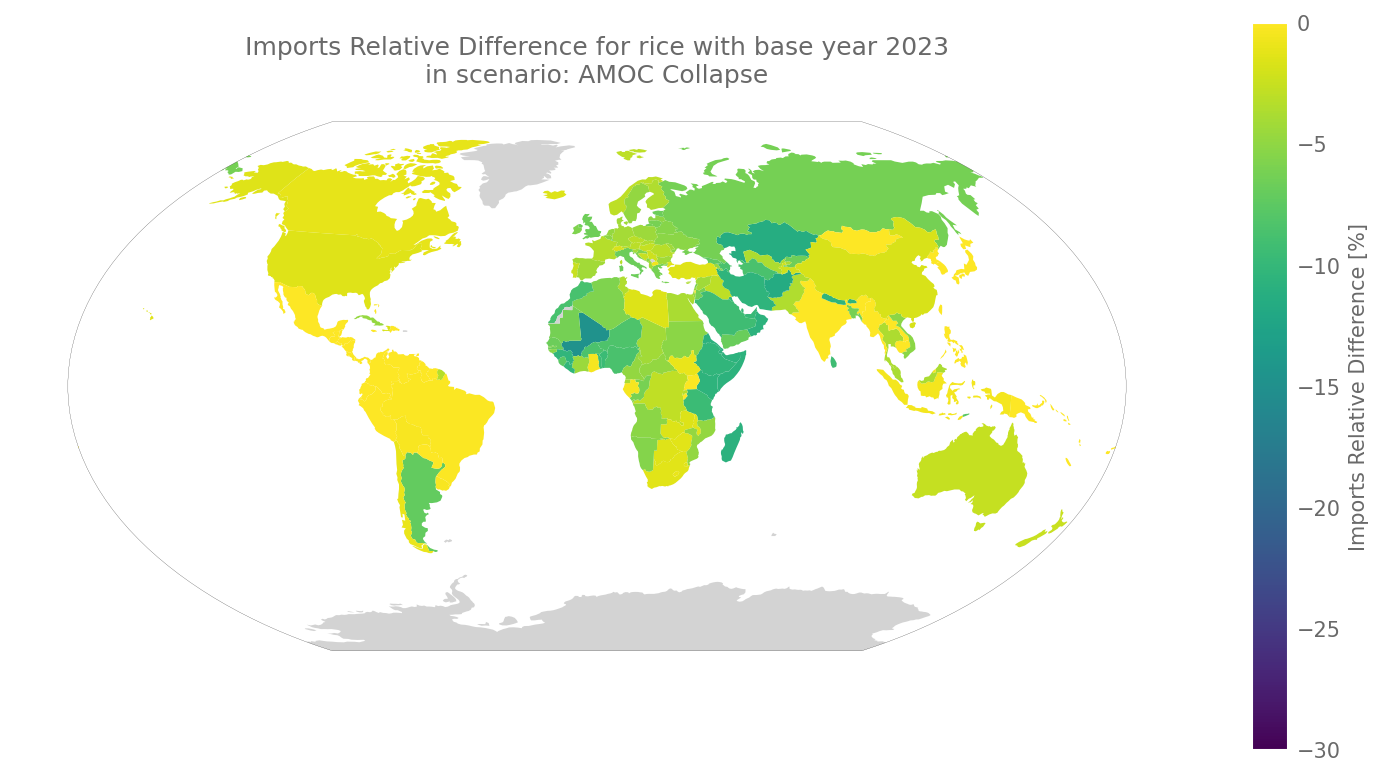

In [12]:
rice_comparison.plot_imports_difference(figsize=(10, 10), vmin=-30, vmax=0, shrink=0.5)

### Trade communities (Rice)

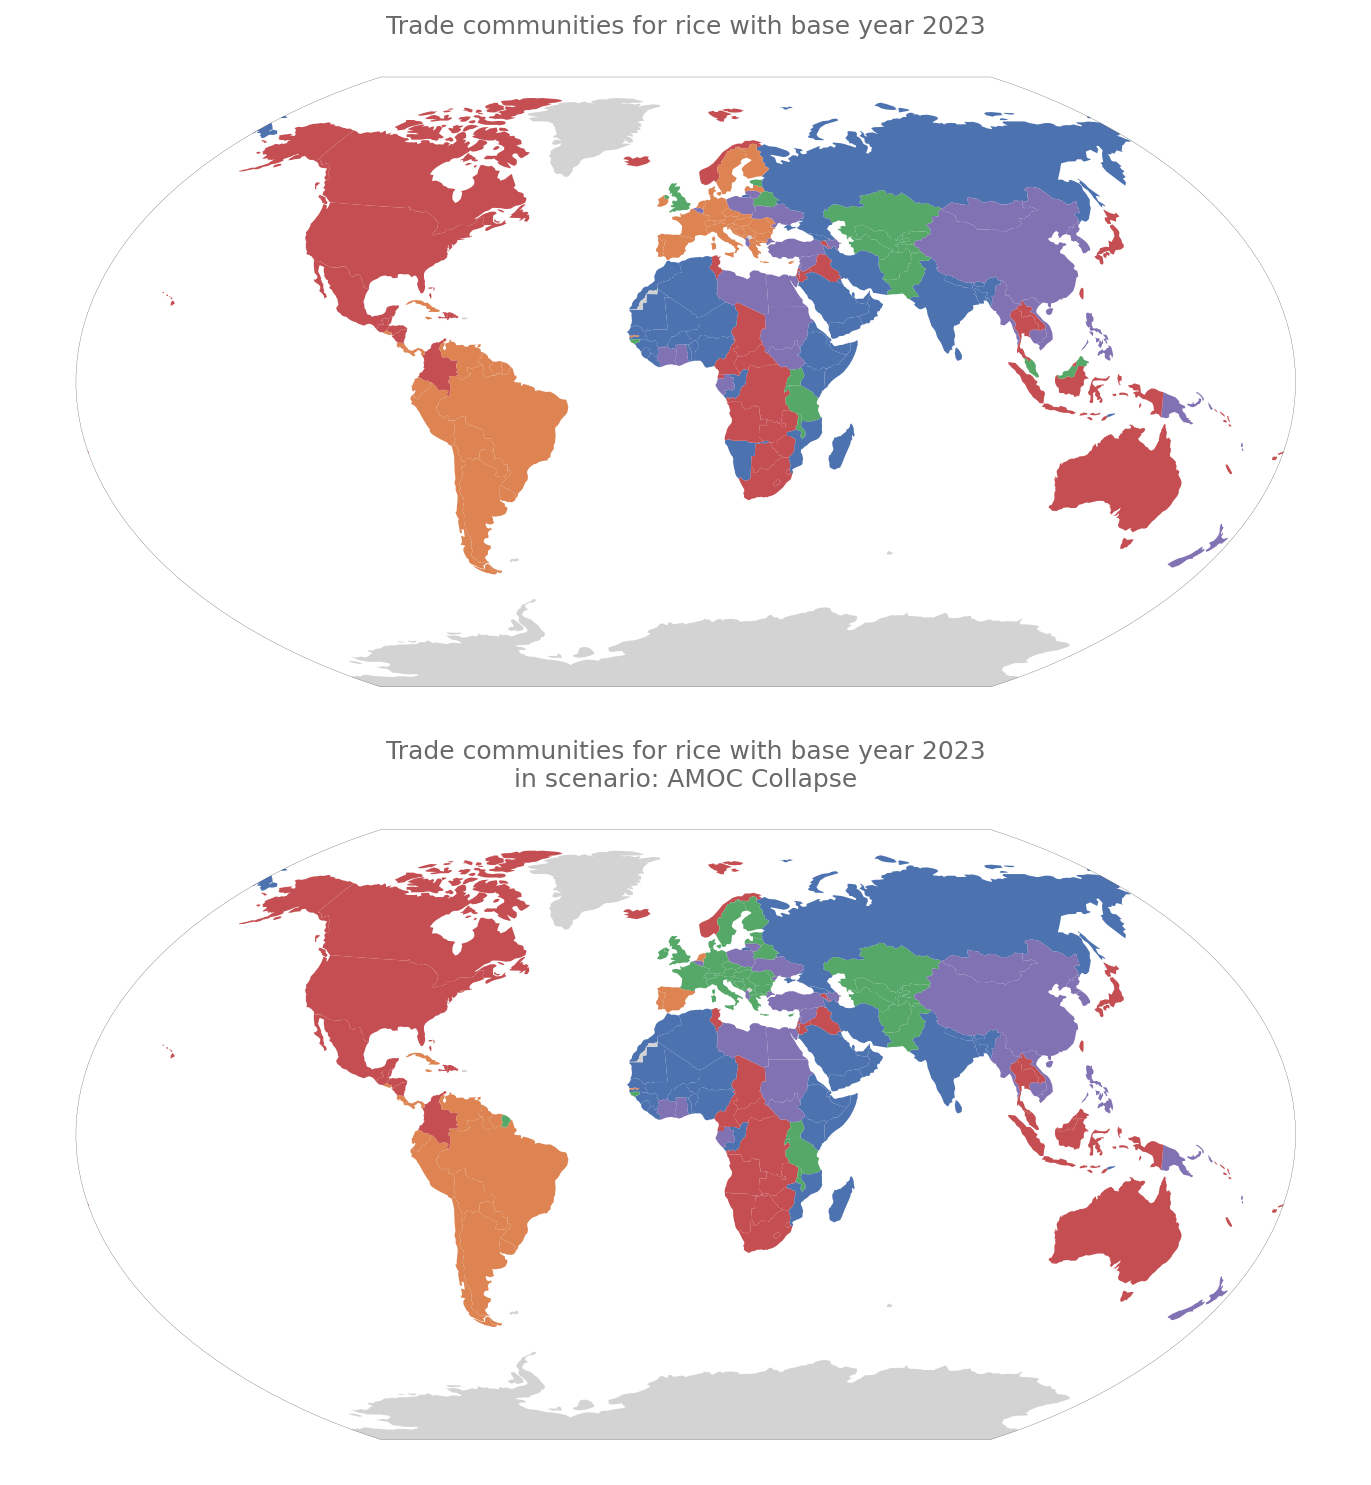

In [13]:
rice_comparison.plot_all_trade_communities(figsize=(15, 10))

### Trade community change — Jaccard distance (Rice)

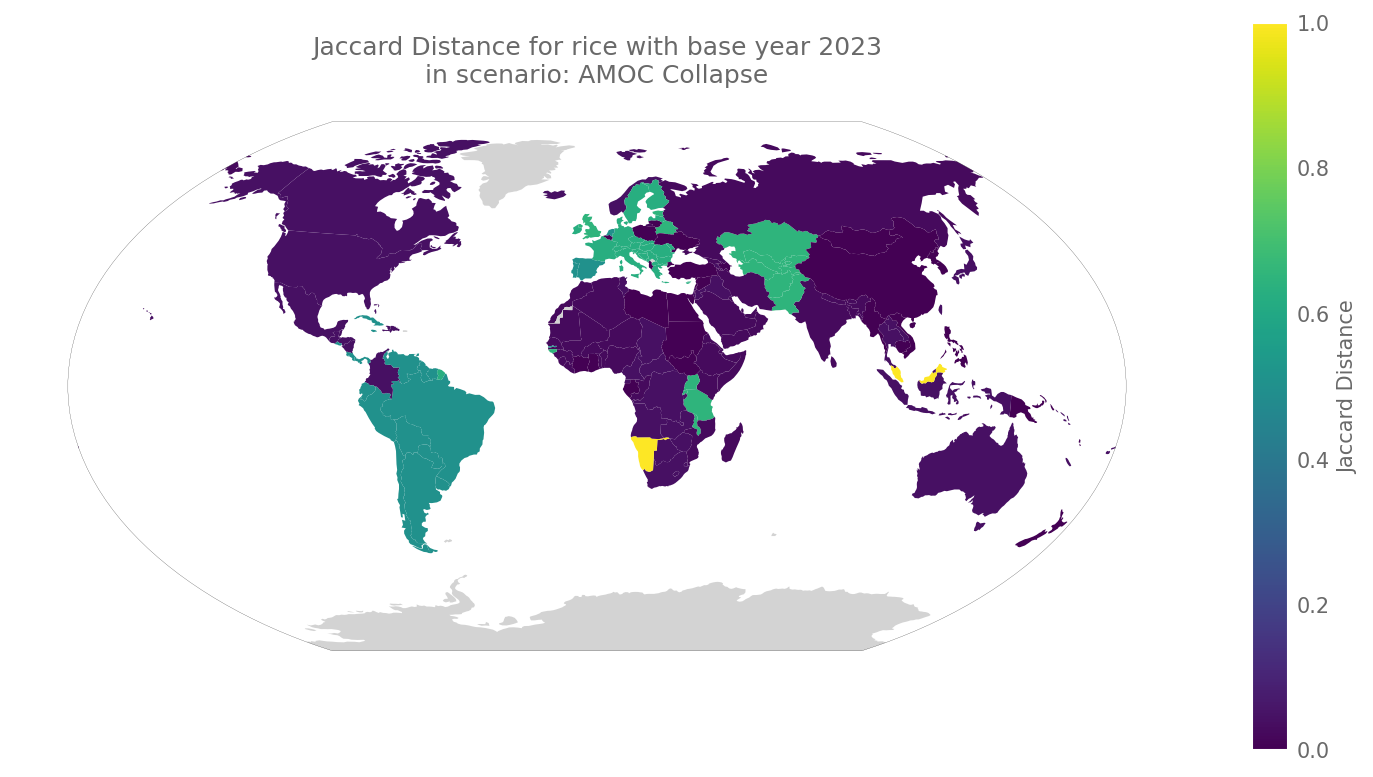

In [14]:
rice_comparison.plot_community_difference(figsize=(10, 10), vmin=0, vmax=1, shrink=0.5)